In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("diabetes.csv")

In [3]:
df.shape


(100000, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [5]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [6]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [7]:
df["diabetes"].value_counts()

diabetes
0    91500
1     8500
Name: count, dtype: int64

In [8]:
df["smoking_history"].unique()

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

In [9]:
import numpy as np

In [10]:
df["smoking_history"] = df["smoking_history"].replace("No Info", np.nan)

In [11]:
df["smoking_history"].isnull().sum()

35816

In [12]:
df['smoking_history'].value_counts()

smoking_history
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

In [13]:
pd.crosstab(df["gender"], df["diabetes"], normalize="index")

diabetes,0,1
gender,,
Female,0.923811,0.076189
Male,0.902510,0.097490
Other,1.000000,0.000000


In [14]:
df["age_group"] = pd.cut(df["age"], bins=[0,30,50,100], labels=["young","middle","old"])

In [15]:
pd.crosstab([df["gender"], df["age_group"]], df["diabetes"], normalize="index")

diabetes                 0         1
gender age_group                    
Female young      0.991079  0.008921
       middle     0.952193  0.047807
       old        0.844718  0.155282
Male   young      0.991067  0.008933
       middle     0.931854  0.068146
       old        0.802515  0.197485
Other  young      1.000000  0.000000
       middle     1.000000  0.000000
       old        1.000000  0.000000

In [16]:
pd.crosstab(df["hypertension"], df["diabetes"], normalize="index")

diabetes,0,1
hypertension,,
0,0.930692,0.069308
1,0.721042,0.278958


In [17]:
pd.crosstab(df["heart_disease"], df["diabetes"], normalize="index")

diabetes,0,1
heart_disease,,
0,0.924702,0.075298
1,0.678590,0.321410


In [18]:
pd.get_dummies(df["smoking_history"])

,current,ever,former,never,not current
0,False,False,False,True,False
1,False,False,False,False,False
2,False,False,False,True,False
3,True,False,False,False,False
4,True,False,False,False,False
...,...,...,...,...,...
99995,False,False,False,False,False
99996,False,False,False,False,False
99997,False,False,True,False,False
99998,False,False,False,True,False


In [19]:
pd.crosstab(df["smoking_history"], df["diabetes"], normalize="index")

diabetes,0,1
smoking_history,,
current,0.897911,0.102089
ever,0.882118,0.117882
former,0.829983,0.170017
never,0.904659,0.095341
not current,0.892973,0.107027


In [20]:
pd.crosstab([df["smoking_history"], df["age_group"]], df["diabetes"], normalize="index")

diabetes                          0         1
smoking_history age_group                    
current         young      0.980234  0.019766
                middle     0.923716  0.076284
                old        0.809732  0.190268
ever            young      0.984828  0.015172
                middle     0.924747  0.075253
                old        0.811808  0.188192
former          young      0.991239  0.008761
                middle     0.922014  0.077986
                old        0.776827  0.223173
never           young      0.987584  0.012416
                middle     0.944851  0.055149
                old        0.808748  0.191252
not current     young      0.982166  0.017834
                middle     0.936952  0.063048
                old        0.820832  0.179168

In [21]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop("diabetes", axis=1)
y = df_encoded["diabetes"]

In [22]:
df_filtered = df[df['gender'].isin(['Male', 'Female'])]

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

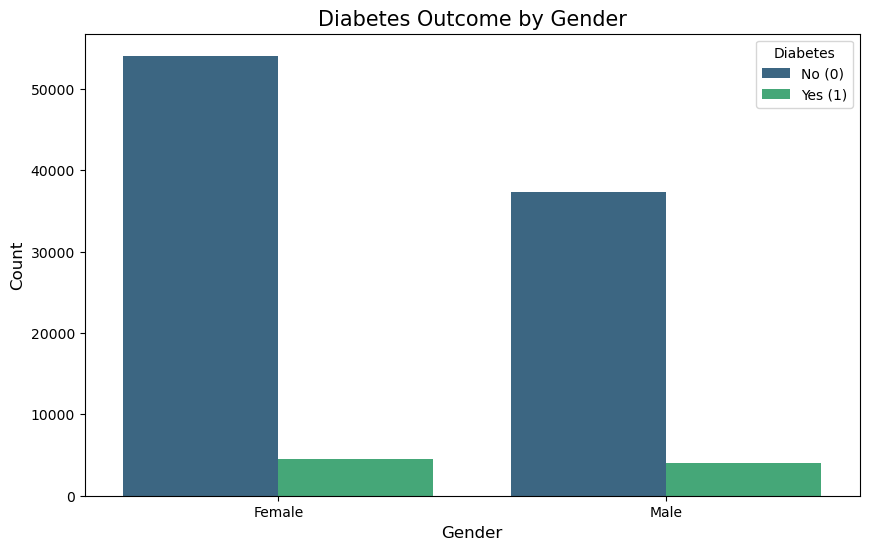

In [24]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_filtered, x='gender', hue='diabetes', palette='viridis')
plt.title('Diabetes Outcome by Gender', fontsize=15)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Diabetes', labels=['No (0)', 'Yes (1)'])

plt.show()

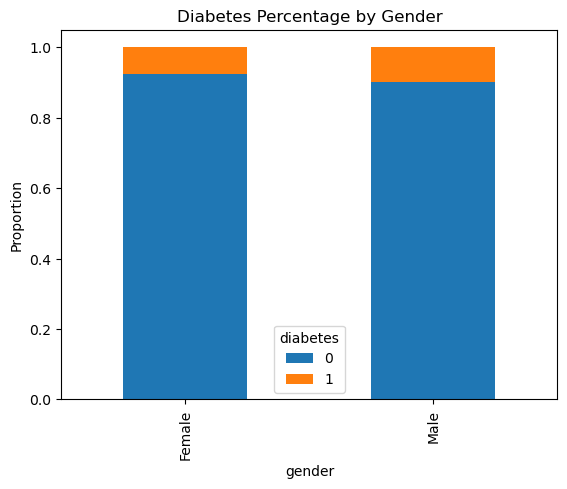

In [25]:
gender_diabetes = pd.crosstab(df_filtered['gender'], df_filtered['diabetes'], normalize='index')

gender_diabetes.plot(kind='bar', stacked=True)
plt.title('Diabetes Percentage by Gender')
plt.ylabel('Proportion')
plt.show()

In [26]:
y = df['diabetes']

X = df.drop(columns=['gender', 'diabetes'])

In [27]:
print(df.columns)

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes', 'age_group'],
      dtype='object')


In [28]:
X = df.drop(columns=['gender', 'diabetes'], errors='ignore')
y = df['diabetes']

In [29]:
print(df.columns)

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes', 'age_group'],
      dtype='object')


In [30]:
print(X.head())

    age  hypertension  heart_disease smoking_history    bmi  HbA1c_level  \
0  80.0             0              1           never  25.19          6.6   
1  54.0             0              0             NaN  27.32          6.6   
2  28.0             0              0           never  27.32          5.7   
3  36.0             0              0         current  23.45          5.0   
4  76.0             1              1         current  20.14          4.8   

   blood_glucose_level age_group  
0                  140       old  
1                   80       old  
2                  158     young  
3                  155    middle  
4                  155       old  


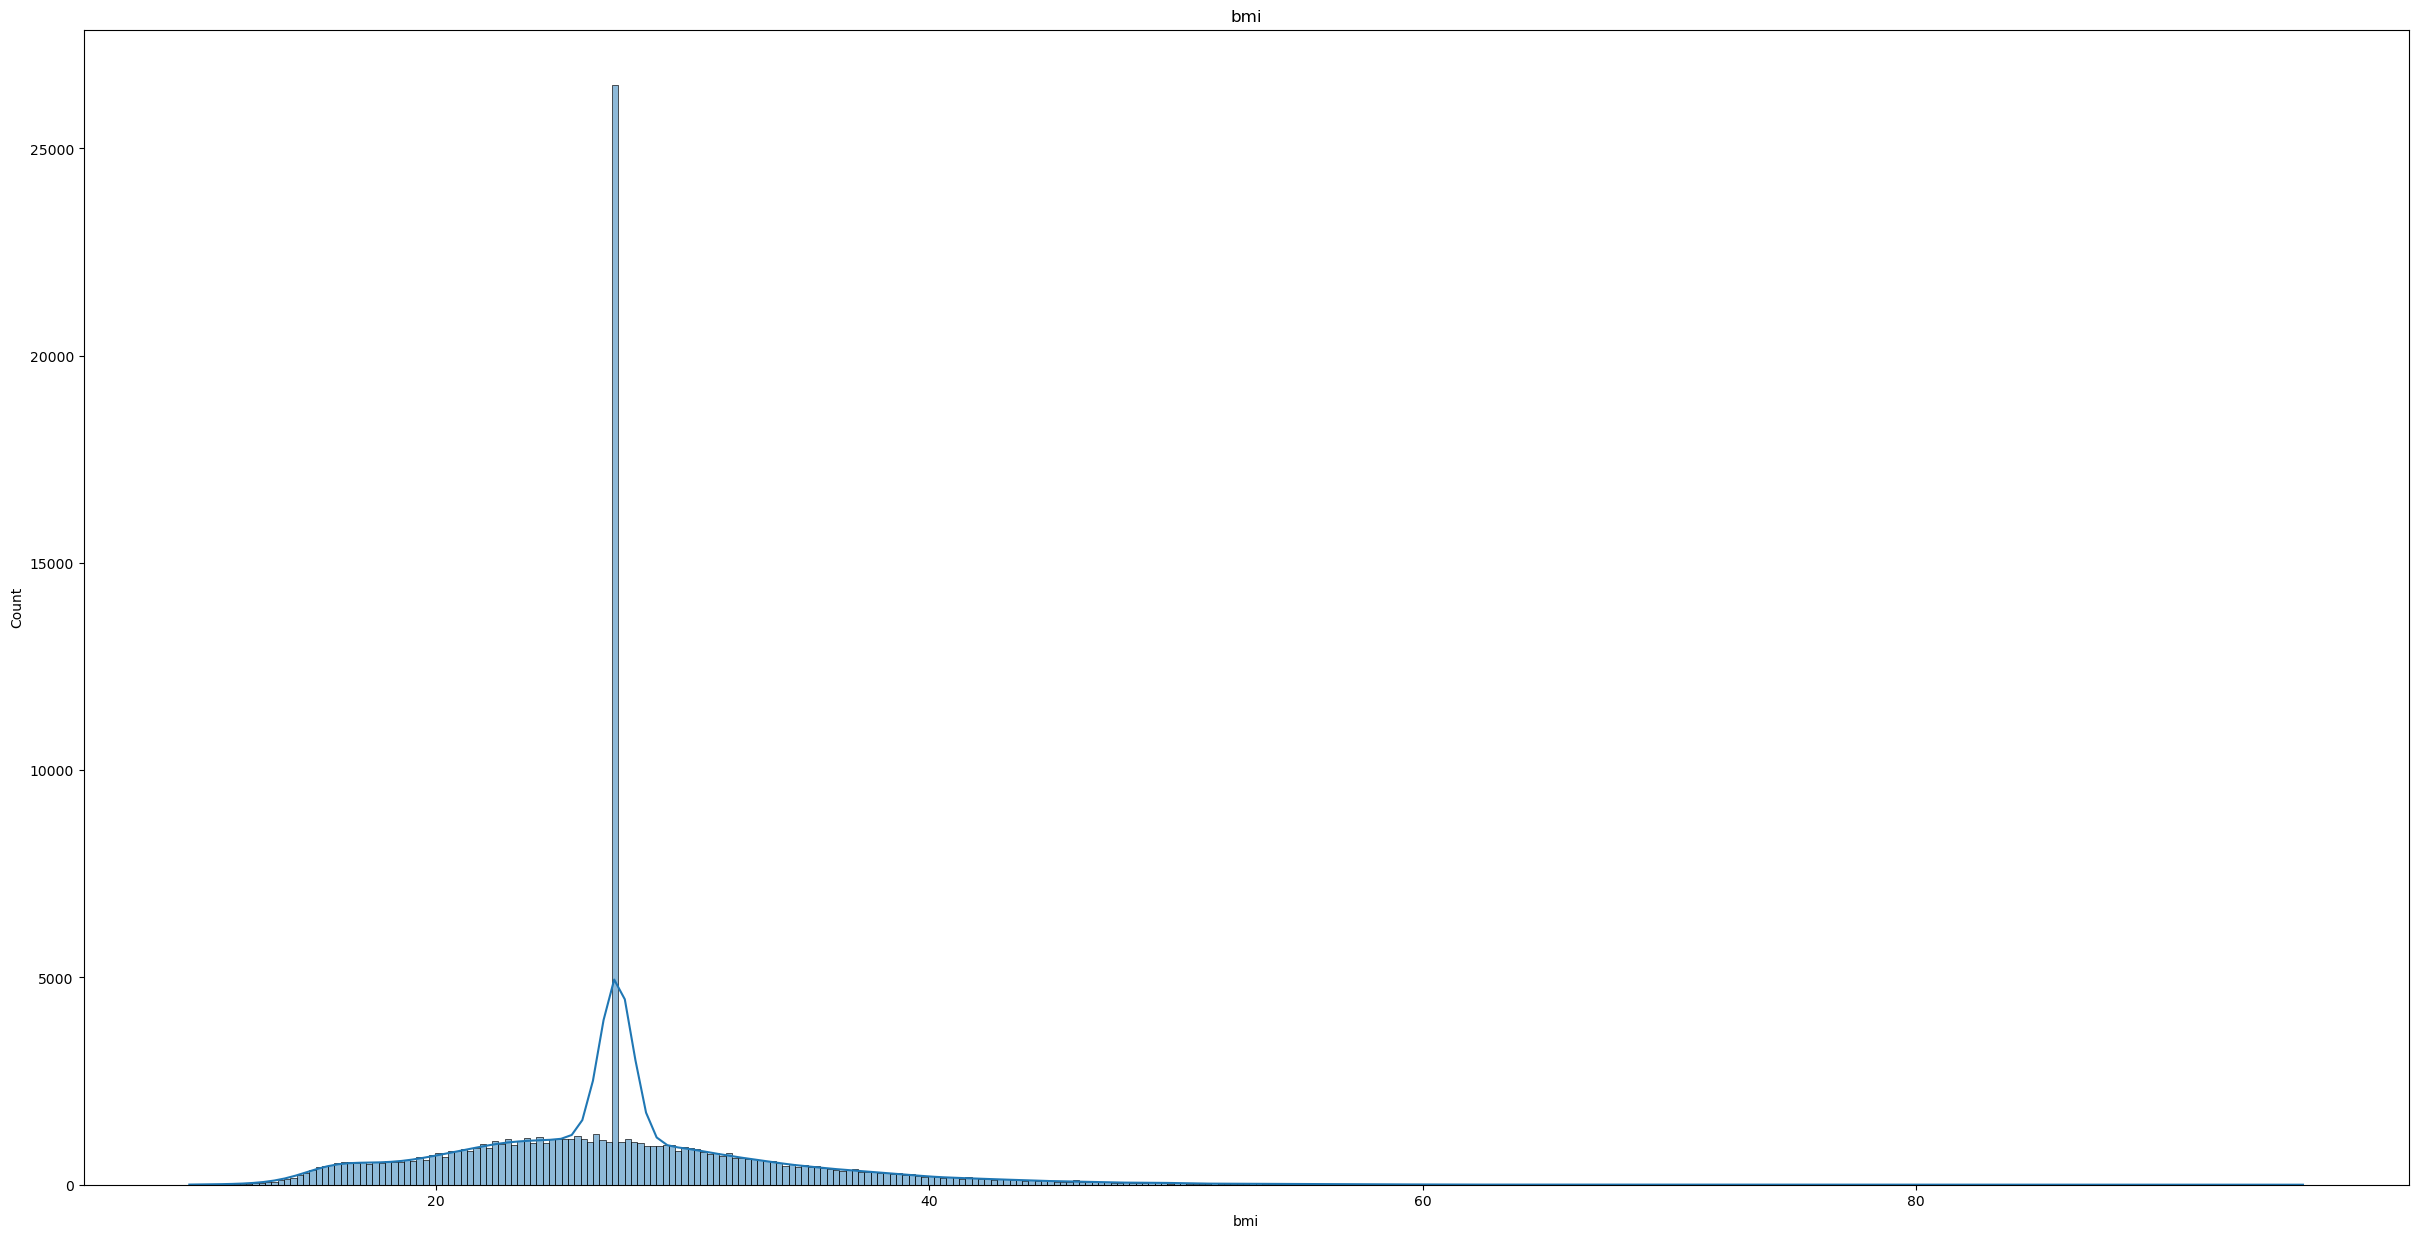

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ["bmi"]

for col in num_cols:
    plt.figure(figsize=(30,15))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [32]:
import numpy as np

# Select numeric columns only
numeric_cols = X.select_dtypes(include=[np.number]).columns

In [33]:
X = pd.get_dummies(X, columns=['smoking_history'], drop_first=True)

In [34]:
print(X.isnull().sum())

age                            0
hypertension                   0
heart_disease                  0
bmi                            0
HbA1c_level                    0
blood_glucose_level            0
age_group                      0
smoking_history_ever           0
smoking_history_former         0
smoking_history_never          0
smoking_history_not current    0
dtype: int64


In [35]:
df["smoking_history"]=df["smoking_history"].fillna("never")

In [36]:
print(df.shape)

(100000, 10)


In [37]:
print(df.columns)

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes', 'age_group'],
      dtype='object')


In [38]:
print(df.dtypes)

gender                   object
age                     float64
hypertension              int64
heart_disease             int64
smoking_history          object
bmi                     float64
HbA1c_level             float64
blood_glucose_level       int64
diabetes                  int64
age_group              category
dtype: object


In [39]:
print(df.isnull().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
age_group              0
dtype: int64


In [40]:
print(X.isnull().sum().sum())

0


In [41]:
print(df["diabetes"].value_counts(normalize=True))

diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64


In [42]:
print(X.columns)

Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'age_group', 'smoking_history_ever',
       'smoking_history_former', 'smoking_history_never',
       'smoking_history_not current'],
      dtype='object')


In [43]:
X.select_dtypes(include='object').columns

Index([], dtype='object')

In [44]:
df_encoded.select_dtypes(include='object').columns

Index([], dtype='object')

In [45]:
print(df_encoded.columns)

Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'diabetes', 'gender_Male', 'gender_Other',
       'smoking_history_ever', 'smoking_history_former',
       'smoking_history_never', 'smoking_history_not current',
       'age_group_middle', 'age_group_old'],
      dtype='object')


In [46]:
print(df_encoded.columns)

Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'diabetes', 'gender_Male', 'gender_Other',
       'smoking_history_ever', 'smoking_history_former',
       'smoking_history_never', 'smoking_history_not current',
       'age_group_middle', 'age_group_old'],
      dtype='object')


In [47]:
df=df.drop("gender",axis=1)

In [48]:
df_encoded=pd.get_dummies(df,drop_first=True)

In [49]:
print(df_encoded.columns)

Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'diabetes', 'smoking_history_ever',
       'smoking_history_former', 'smoking_history_never',
       'smoking_history_not current', 'age_group_middle', 'age_group_old'],
      dtype='object')


In [50]:
X.select_dtypes(include='object').columns

Index([], dtype='object')

In [51]:
print(X.columns)

Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'age_group', 'smoking_history_ever',
       'smoking_history_former', 'smoking_history_never',
       'smoking_history_not current'],
      dtype='object')


In [52]:
X.select_dtypes(include='object').columns

Index([], dtype='object')

In [53]:
print(X.columns)

Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'age_group', 'smoking_history_ever',
       'smoking_history_former', 'smoking_history_never',
       'smoking_history_not current'],
      dtype='object')


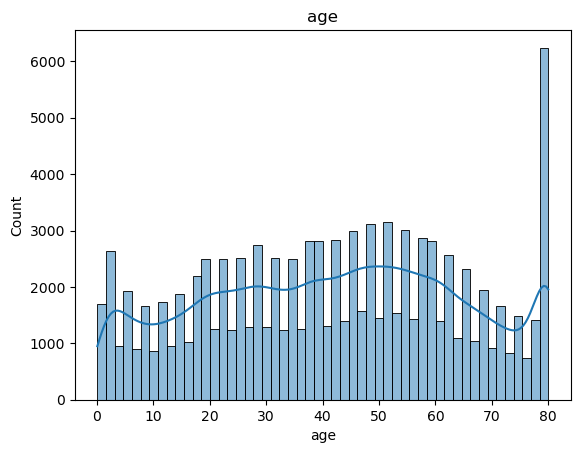

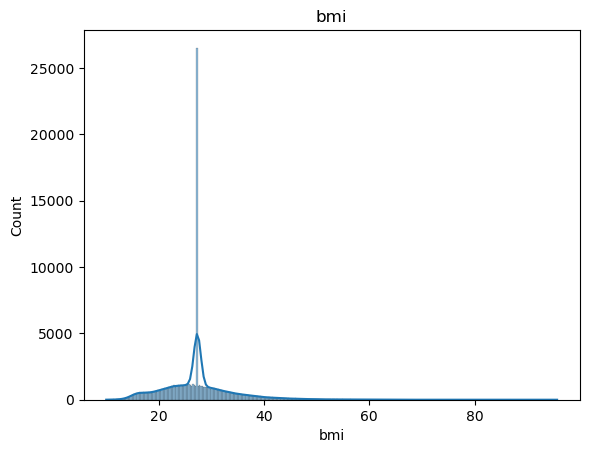

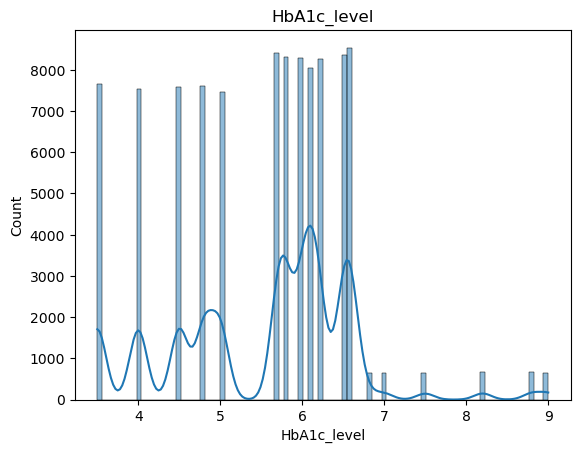

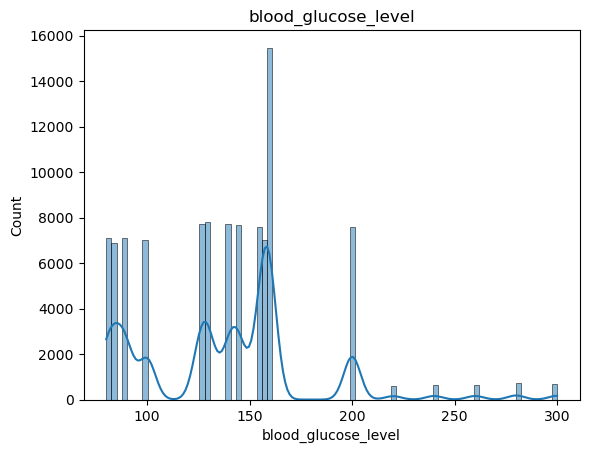

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

cols=["age","bmi", "HbA1c_level","blood_glucose_level"]

for col in cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [55]:
corr=df_encoded.corr()
print(corr["diabetes"].sort_values(ascending=False))

diabetes                       1.000000
blood_glucose_level            0.419558
HbA1c_level                    0.400660
age                            0.258008
age_group_old                  0.249167
bmi                            0.214357
hypertension                   0.197823
heart_disease                  0.171727
smoking_history_former         0.097917
smoking_history_ever           0.024080
smoking_history_not current    0.020734
age_group_middle              -0.065174
smoking_history_never         -0.096907
Name: diabetes, dtype: float64


In [56]:
df.groupby("diabetes")[["bmi","HbA1c_level","blood_glucose_level"]].mean()

,bmi,HbA1c_level,blood_glucose_level
diabetes,,,
0,26.887163,5.396761,132.852470
1,31.988382,6.934953,194.094706


In [57]:
print(X.isnull().sum().sum())

0


In [58]:
print(df_encoded.corr().loc['HbA1c_level','blood_glucose_level'])

0.16673292982890464


In [59]:
pd.crosstab(df["smoking_history"],df["diabetes"], normalize="index")

diabetes,0,1
smoking_history,,
current,0.897911,0.102089
ever,0.882118,0.117882
former,0.829983,0.170017
never,0.932310,0.067690
not current,0.892973,0.107027


In [60]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("diabetes", axis=1)
y = df_encoded["diabetes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [61]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [62]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_res, y_train_res)

LogisticRegression(max_iter=1000)

In [63]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.90      0.94     18300
           1       0.44      0.83      0.57      1700

    accuracy                           0.89     20000
   macro avg       0.71      0.87      0.76     20000
weighted avg       0.94      0.89      0.91     20000



In [64]:
print(y_train.value_counts())
print(y_train_res.value_counts())

diabetes
0    73200
1     6800
Name: count, dtype: int64
diabetes
1    73200
0    73200
Name: count, dtype: int64


In [65]:
df.shape

(100000, 9)

In [66]:
print(X_train.shape)
print(X_train_res.shape)

(80000, 12)
(146400, 12)


In [67]:
def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return len(outliers), lower, upper

In [68]:
for col in ['age','bmi','HbA1c_level','blood_glucose_level']:
    print(col, detect_outliers(df, col))

age (0, -30.0, 114.0)
bmi (7086, 14.705, 38.504999999999995)
HbA1c_level (1315, 2.6999999999999993, 8.3)
blood_glucose_level (2038, 11.5, 247.5)


<Axes: xlabel='bmi', ylabel='Count'>

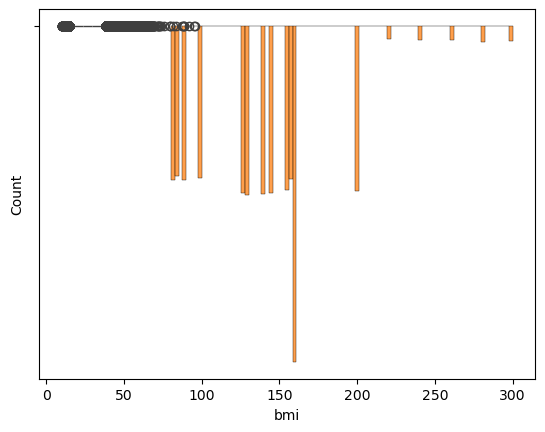

In [69]:
sns.boxplot(x=df['bmi'])
sns.histplot(df['blood_glucose_level'])

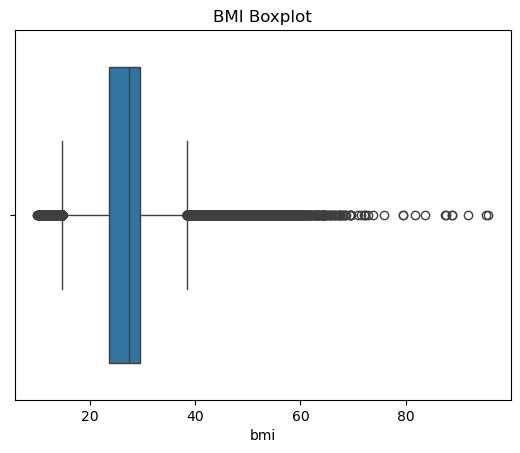

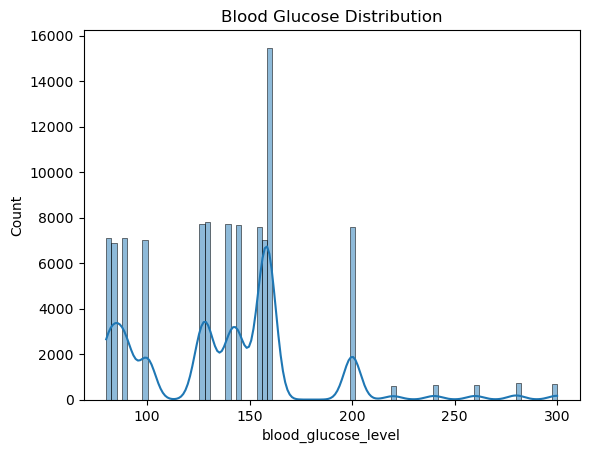

In [70]:
import matplotlib.pyplot as plt

plt.figure()
sns.boxplot(x=df['bmi'])
plt.title("BMI Boxplot")
plt.show()

plt.figure()
sns.histplot(df['blood_glucose_level'], kde=True)
plt.title("Blood Glucose Distribution")
plt.show()

<Axes: xlabel='bmi'>

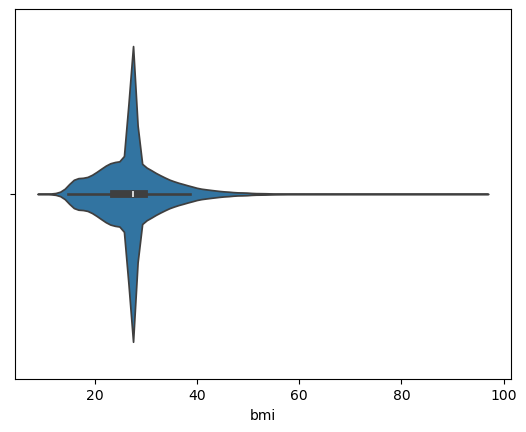

In [71]:
sns.violinplot(x=df['bmi'])

<Axes: xlabel='blood_glucose_level', ylabel='Count'>

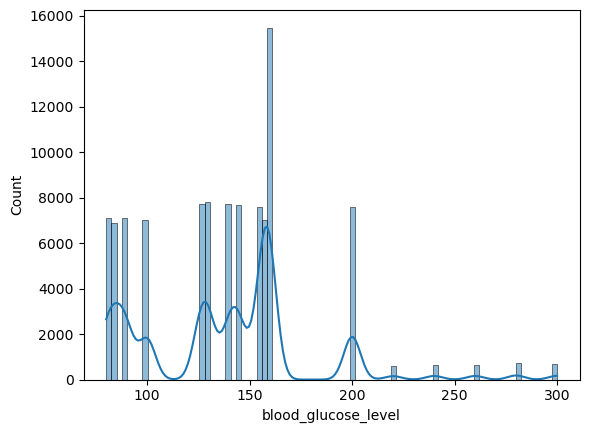

In [72]:
sns.histplot(df['blood_glucose_level'], kde=True)

<Axes: xlabel='HbA1c_level', ylabel='Count'>

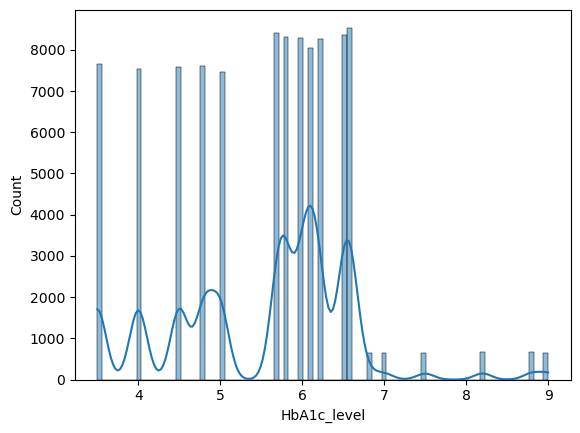

In [73]:
sns.histplot(df['HbA1c_level'], kde=True)

<Axes: xlabel='bmi', ylabel='Count'>

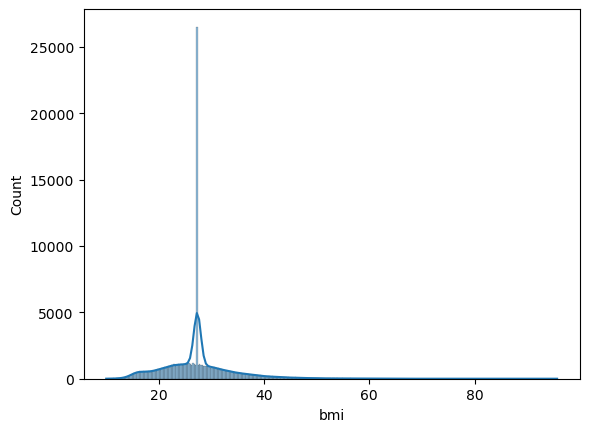

In [74]:
sns.histplot(df['bmi'], kde=True)

<Axes: xlabel='blood_glucose_level', ylabel='Count'>

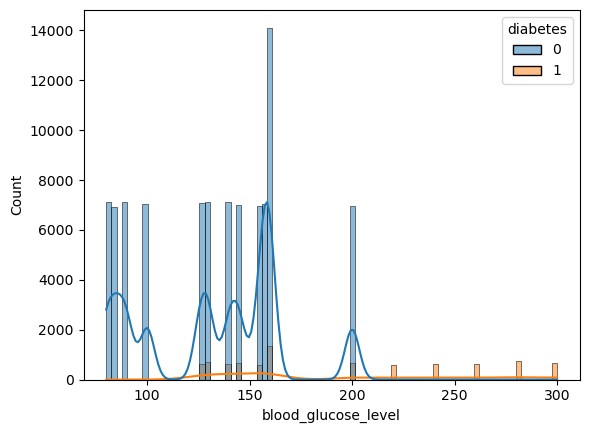

In [75]:
sns.histplot(data=df, x='blood_glucose_level', hue='diabetes', kde=True)

<Axes: xlabel='diabetes', ylabel='HbA1c_level'>

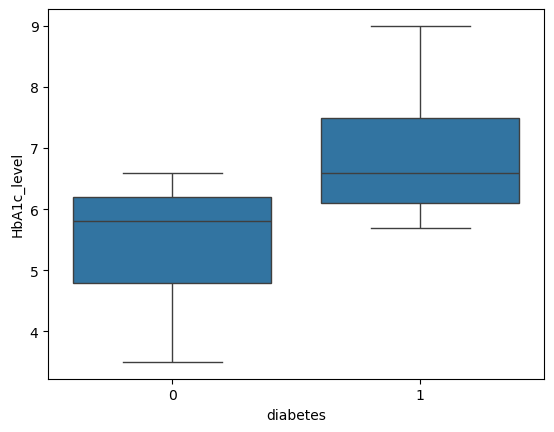

In [76]:
sns.boxplot(x='diabetes', y='HbA1c_level', data=df)

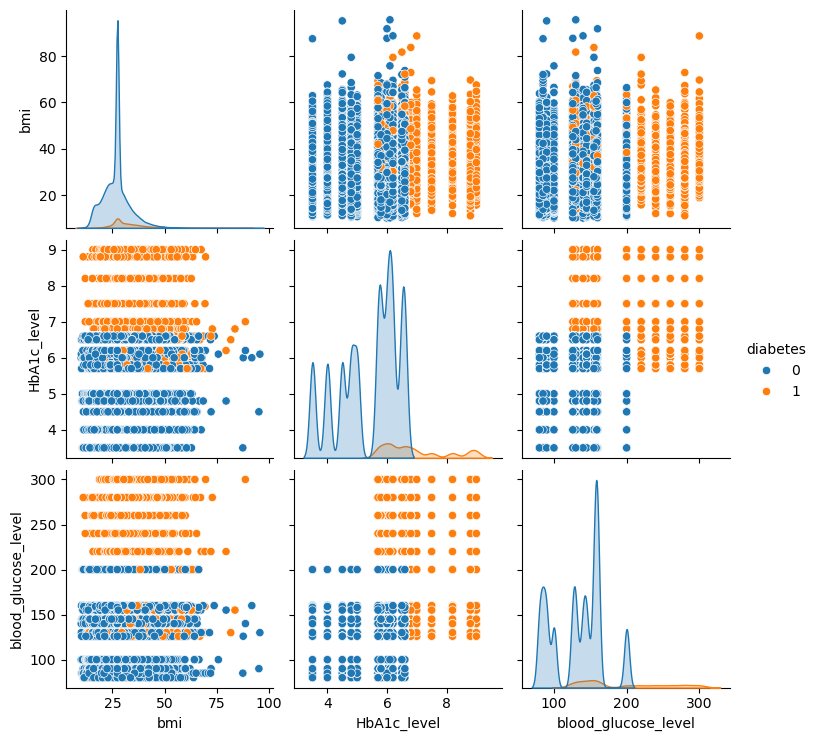

In [77]:
sns.pairplot(df[['bmi','HbA1c_level','blood_glucose_level','diabetes']], hue='diabetes')

<Axes: >

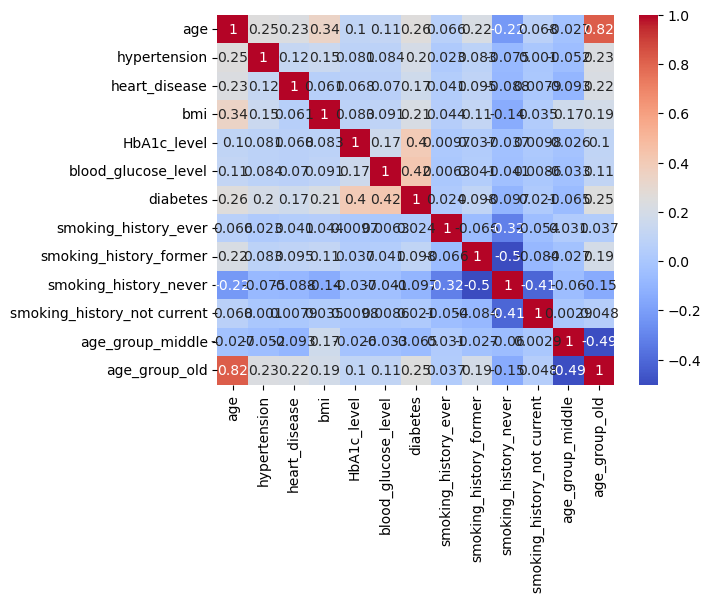

In [78]:
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')

In [79]:
from imblearn.over_sampling import SMOTE

X = df_encoded.drop("diabetes", axis=1)
y = df_encoded["diabetes"]

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print(y_res.value_counts())

diabetes
0    91500
1    91500
Name: count, dtype: int64


In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

In [81]:
#check if oversampled
print(y_train.value_counts())
print(y_test.value_counts())

diabetes
0    73207
1    73193
Name: count, dtype: int64
diabetes
1    18307
0    18293
Name: count, dtype: int64


In [82]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [83]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90     18293
           1       0.90      0.89      0.90     18307

    accuracy                           0.90     36600
   macro avg       0.90      0.90      0.90     36600
weighted avg       0.90      0.90      0.90     36600

[[16423  1870]
 [ 1926 16381]]


In [84]:
import numpy as np
print(np.bincount(y_pred))

[18349 18251]


<Axes: >

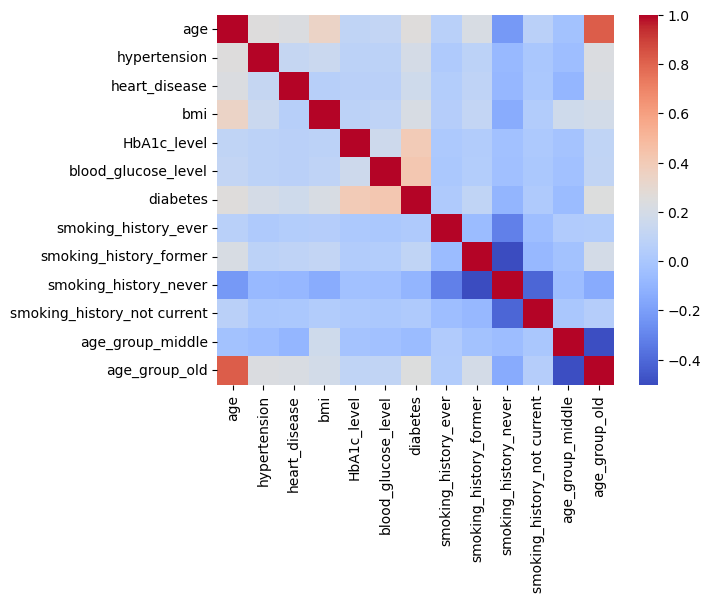

In [85]:
import seaborn as sns
sns.heatmap(df_encoded.corr(), cmap="coolwarm")


In [86]:
#actual model weights
import pandas as pd

weights = pd.Series(model.coef_[0], index=X.columns)
weights = weights.sort_values(ascending=False)
print(weights)

smoking_history_former         2.497769
HbA1c_level                    2.476763
smoking_history_ever           2.334727
smoking_history_never          2.315323
smoking_history_not current    2.076933
age_group_old                  1.107859
age_group_middle               0.786602
bmi                            0.089637
age                            0.037778
blood_glucose_level            0.032022
hypertension                  -0.205449
heart_disease                 -0.302253
dtype: float64


In [87]:
import pandas as pd

# Save training column order once (VERY important)
feature_columns = X.columns  # make sure this is from your training data

def test_model():
    try:
        # ---- INPUT SECTION ----
        age = int(input("Enter age (0–100): "))
        hypertension = int(input("Hypertension (0 or 1): "))
        heart_disease = int(input("Heart disease (0 or 1): "))
        bmi = float(input("Enter BMI (10–60): "))
        hba1c = float(input("Enter HbA1c level (3–12): "))
        glucose = float(input("Enter blood glucose level (50–300): "))

        print("\nSmoking options: ever, former, never, not current")
        smoking_type = input("Enter smoking history: ").strip().lower()

        # ---- VALIDATION ----
        if smoking_type not in ["ever", "former", "never", "not current"]:
            print("❌ Invalid smoking type")
            return

        if not (0 <= age <= 100):
            print("❌ Invalid age")
            return

        if hypertension not in [0, 1] or heart_disease not in [0, 1]:
            print("❌ Hypertension/Heart disease must be 0 or 1")
            return

        if not (10 <= bmi <= 60):
            print("❌ BMI out of range")
            return

        # ---- ENCODING ----
        data = {
            "age": age,
            "hypertension": hypertension,
            "heart_disease": heart_disease,
            "bmi": bmi,
            "HbA1c_level": hba1c,
            "blood_glucose_level": glucose,
            "smoking_history_ever": 0,
            "smoking_history_former": 0,
            "smoking_history_never": 0,
            "smoking_history_not current": 0
        }

        data[f"smoking_history_{smoking_type}"] = 1

        # ---- CREATE DATAFRAME ----
        df_test = pd.DataFrame([data])

        # ---- ENSURE COLUMN ORDER MATCHES TRAINING ----
        df_test = df_test.reindex(columns=feature_columns, fill_value=0)

        print("\nInput Data:")
        print(df_test)

        # ---- APPLY SCALING (if exists) ----
        if 'scaler' in globals():
            df_test = scaler.transform(df_test)

        # ---- PREDICTION ----
        prob = model.predict_proba(df_test)[0][1]

        # ---- CUSTOM THRESHOLD (better than default 0.5) ----
        threshold = 0.7
        pred = 1 if prob > threshold else 0

        print("\nProbability of Diabetes:", round(prob, 3))
        print("Prediction:", "Diabetic" if pred else "Not Diabetic")

    except ValueError:
        print("❌ Invalid input type (enter numbers only)")
    except Exception as e:
        print("⚠ Error:", str(e))

In [88]:
test_model()

Enter age (0–100):  65
Hypertension (0 or 1):  1
Heart disease (0 or 1):  1
Enter BMI (10–60):  34
Enter HbA1c level (3–12):  8.5
Enter blood glucose level (50–300):  215



Smoking options: ever, former, never, not current


Enter smoking history:  former



Input Data:
   age  hypertension  heart_disease   bmi  HbA1c_level  blood_glucose_level  \
0   65             1              1  34.0          8.5                215.0   

   smoking_history_ever  smoking_history_former  smoking_history_never  \
0                     0                       1                      0   

   smoking_history_not current  age_group_middle  age_group_old  
0                            0                 0              0  

Probability of Diabetes: 0.999
Prediction: Diabetic


In [89]:
test_model()

Enter age (0–100):  2
Hypertension (0 or 1):  1
Heart disease (0 or 1):  1
Enter BMI (10–60):  1
Enter HbA1c level (3–12):  1
Enter blood glucose level (50–300):  1



Smoking options: ever, former, never, not current


Enter smoking history:  never


❌ BMI out of range


In [90]:
test_model()

Enter age (0–100):  22
Hypertension (0 or 1):  0
Heart disease (0 or 1):  0
Enter BMI (10–60):  21.0
Enter HbA1c level (3–12):  4.8
Enter blood glucose level (50–300):  88



Smoking options: ever, former, never, not current


Enter smoking history:  never



Input Data:
   age  hypertension  heart_disease   bmi  HbA1c_level  blood_glucose_level  \
0   22             0              0  21.0          4.8                 88.0   

   smoking_history_ever  smoking_history_former  smoking_history_never  \
0                     0                       0                      1   

   smoking_history_not current  age_group_middle  age_group_old  
0                            0                 0              0  

Probability of Diabetes: 0.0
Prediction: Not Diabetic


In [91]:
test_model()


Enter age (0–100):  28
Hypertension (0 or 1):  0
Heart disease (0 or 1):  0
Enter BMI (10–60):  19.5
Enter HbA1c level (3–12):  7.6
Enter blood glucose level (50–300):  180



Smoking options: ever, former, never, not current


Enter smoking history:  never



Input Data:
   age  hypertension  heart_disease   bmi  HbA1c_level  blood_glucose_level  \
0   28             0              0  19.5          7.6                180.0   

   smoking_history_ever  smoking_history_former  smoking_history_never  \
0                     0                       0                      1   

   smoking_history_not current  age_group_middle  age_group_old  
0                            0                 0              0  

Probability of Diabetes: 0.824
Prediction: Diabetic


In [92]:
test_model()

Enter age (0–100):  58
Hypertension (0 or 1):  1
Heart disease (0 or 1):  0
Enter BMI (10–60):  38.5
Enter HbA1c level (3–12):  5.4
Enter blood glucose level (50–300):  95



Smoking options: ever, former, never, not current


Enter smoking history:  never



Input Data:
   age  hypertension  heart_disease   bmi  HbA1c_level  blood_glucose_level  \
0   58             1              0  38.5          5.4                 95.0   

   smoking_history_ever  smoking_history_former  smoking_history_never  \
0                     0                       0                      1   

   smoking_history_not current  age_group_middle  age_group_old  
0                            0                 0              0  

Probability of Diabetes: 0.018
Prediction: Not Diabetic


In [93]:
test_model()
#type 1 diabetes

Enter age (0–100):  14
Hypertension (0 or 1):  0
Heart disease (0 or 1):  0
Enter BMI (10–60):  18.5
Enter HbA1c level (3–12):  9.5
Enter blood glucose level (50–300):  250



Smoking options: ever, former, never, not current


Enter smoking history:  never



Input Data:
   age  hypertension  heart_disease   bmi  HbA1c_level  blood_glucose_level  \
0   14             0              0  18.5          9.5                250.0   

   smoking_history_ever  smoking_history_former  smoking_history_never  \
0                     0                       0                      1   

   smoking_history_not current  age_group_middle  age_group_old  
0                            0                 0              0  

Probability of Diabetes: 1.0
Prediction: Diabetic


In [94]:
test_model()
#type 2 diabetes

Enter age (0–100):  55
Hypertension (0 or 1):  1
Heart disease (0 or 1):  0
Enter BMI (10–60):  32
Enter HbA1c level (3–12):  7.8
Enter blood glucose level (50–300):  165



Smoking options: ever, former, never, not current


Enter smoking history:  former



Input Data:
   age  hypertension  heart_disease   bmi  HbA1c_level  blood_glucose_level  \
0   55             1              0  32.0          7.8                165.0   

   smoking_history_ever  smoking_history_former  smoking_history_never  \
0                     0                       1                      0   

   smoking_history_not current  age_group_middle  age_group_old  
0                            0                 0              0  

Probability of Diabetes: 0.975
Prediction: Diabetic


In [95]:
test_model()
#gestational diabetes

Enter age (0–100):  29
Hypertension (0 or 1):  0
Heart disease (0 or 1):  0
Enter BMI (10–60):  27.5
Enter HbA1c level (3–12):  5.6
Enter blood glucose level (50–300):  175



Smoking options: ever, former, never, not current


Enter smoking history:  never



Input Data:
   age  hypertension  heart_disease   bmi  HbA1c_level  blood_glucose_level  \
0   29             0              0  27.5          5.6                175.0   

   smoking_history_ever  smoking_history_former  smoking_history_never  \
0                     0                       0                      1   

   smoking_history_not current  age_group_middle  age_group_old  
0                            0                 0              0  

Probability of Diabetes: 0.056
Prediction: Not Diabetic


In [96]:
test_model()

Enter age (0–100):  42
Hypertension (0 or 1):  0
Heart disease (0 or 1):  0
Enter BMI (10–60):  22.0
Enter HbA1c level (3–12):  8.2
Enter blood glucose level (50–300):  190



Smoking options: ever, former, never, not current


Enter smoking history:  never



Input Data:
   age  hypertension  heart_disease   bmi  HbA1c_level  blood_glucose_level  \
0   42             0              0  22.0          8.2                190.0   

   smoking_history_ever  smoking_history_former  smoking_history_never  \
0                     0                       0                      1   

   smoking_history_not current  age_group_middle  age_group_old  
0                            0                 0              0  

Probability of Diabetes: 0.984
Prediction: Diabetic


In [97]:
test_model()
#conflicting bloodwork

Enter age (0–100):  52
Hypertension (0 or 1):  1
Heart disease (0 or 1):  0
Enter BMI (10–60):  29.5
Enter HbA1c level (3–12):  5.6
Enter blood glucose level (50–300):  135



Smoking options: ever, former, never, not current


Enter smoking history:  former



Input Data:
   age  hypertension  heart_disease   bmi  HbA1c_level  blood_glucose_level  \
0   52             1              0  29.5          5.6                135.0   

   smoking_history_ever  smoking_history_former  smoking_history_never  \
0                     0                       1                      0   

   smoking_history_not current  age_group_middle  age_group_old  
0                            0                 0              0  

Probability of Diabetes: 0.044
Prediction: Not Diabetic


In [98]:
test_model()
#silent positive

Enter age (0–100):  61
Hypertension (0 or 1):  0
Heart disease (0 or 1):  0
Enter BMI (10–60):  26.0
Enter HbA1c level (3–12):  6.6
Enter blood glucose level (50–300):  95



Smoking options: ever, former, never, not current


Enter smoking history:  never



Input Data:
   age  hypertension  heart_disease   bmi  HbA1c_level  blood_glucose_level  \
0   61             0              0  26.0          6.6                 95.0   

   smoking_history_ever  smoking_history_former  smoking_history_never  \
0                     0                       0                      1   

   smoking_history_not current  age_group_middle  age_group_old  
0                            0                 0              0  

Probability of Diabetes: 0.139
Prediction: Not Diabetic


In [99]:
test_model()
#prediabetic

Enter age (0–100):  44
Hypertension (0 or 1):  0
Heart disease (0 or 1):  0
Enter BMI (10–60):  28.5
Enter HbA1c level (3–12):  6.4
Enter blood glucose level (50–300):  125



Smoking options: ever, former, never, not current


Enter smoking history:  ever



Input Data:
   age  hypertension  heart_disease   bmi  HbA1c_level  blood_glucose_level  \
0   44             0              0  28.5          6.4                125.0   

   smoking_history_ever  smoking_history_former  smoking_history_never  \
0                     1                       0                      0   

   smoking_history_not current  age_group_middle  age_group_old  
0                            0                 0              0  

Probability of Diabetes: 0.147
Prediction: Not Diabetic


In [100]:
test_model()
#age high

Enter age (0–100):  78
Hypertension (0 or 1):  1
Heart disease (0 or 1):  1
Enter BMI (10–60):  24
Enter HbA1c level (3–12):  5.9
Enter blood glucose level (50–300):  105



Smoking options: ever, former, never, not current


Enter smoking history:  not current



Input Data:
   age  hypertension  heart_disease   bmi  HbA1c_level  blood_glucose_level  \
0   78             1              1  24.0          5.9                105.0   

   smoking_history_ever  smoking_history_former  smoking_history_never  \
0                     0                       0                      0   

   smoking_history_not current  age_group_middle  age_group_old  
0                            1                 0              0  

Probability of Diabetes: 0.029
Prediction: Not Diabetic
